In [1]:
import pandas as pd
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [2]:
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Dataset shape: (23486, 11)

First 5 rows:


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,23486.0,NaN,NaN,NaN,11742.5,6779.968547,0.0,5871.25,11742.5,17613.75,23485.0
Clothing ID,23486.0,NaN,NaN,NaN,918.118709,203.29898,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,NaN,NaN,NaN,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Title,19676,13993,Love it!,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Text,22641,22634,Perfect fit and i've gotten so many compliment...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,23486.0,NaN,NaN,NaN,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,NaN,NaN,NaN,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,NaN,NaN,NaN,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0
Division Name,23472,3,General,13850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department Name,23472,6,Tops,10468,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Column data types:")
display(df.dtypes.to_frame("dtype"))

print("\nNumber of unique values:")
display(df.nunique().to_frame("unique_values"))

print("\nTarget distribution:")
display(df["Recommended IND"].value_counts())

Column data types:


,dtype
Unnamed: 0,int64
Clothing ID,int64
Age,int64
Title,str
Review Text,str
Rating,int64
Recommended IND,int64
Positive Feedback Count,int64
Division Name,str
Department Name,str



Number of unique values:


,unique_values
Unnamed: 0,23486
Clothing ID,1206
Age,77
Title,13993
Review Text,22634
Rating,5
Recommended IND,2
Positive Feedback Count,82
Division Name,3
Department Name,6



Target distribution:


Recommended IND
1    19314
0     4172
Name: count, dtype: int64

In [4]:
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

display(missing[missing["Missing Count"] > 0].sort_values(
    "Missing Count", ascending=False
))

,Missing Count,Missing Percentage
Title,3810,16.22
Review Text,845,3.60
Division Name,14,0.06
Department Name,14,0.06
Class Name,14,0.06


In [5]:
duplicate_count = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_count)

Number of duplicated rows: 0


In [6]:
invalid_checks = {
    "Age <= 0": (df["Age"] <= 0).sum(),
    "Rating outside 1-5": (~df["Rating"].between(1, 5)).sum(),
    "Recommended IND not 0/1": (~df["Recommended IND"].isin([0, 1])).sum(),
    "Positive Feedback Count < 0": (df["Positive Feedback Count"] < 0).sum()
}

invalid_df = pd.DataFrame.from_dict(
    invalid_checks,
    orient="index",
    columns=["Invalid Count"]
)

display(invalid_df)

,Invalid Count
Age <= 0,0
Rating outside 1-5,0
Recommended IND not 0/1,0
Positive Feedback Count < 0,0


In [7]:
numeric_features = [
    "Age",
    "Rating",
    "Positive Feedback Count"
]

outlier_results = []

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_results.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count,
        "Outlier Percentage": round(count / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_results)

display(outlier_df)

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Age,34.0,52.0,7.0,79.0,109,0.46
1,Rating,4.0,5.0,2.5,6.5,2407,10.25
2,Positive Feedback Count,0.0,3.0,-4.5,7.5,2147,9.14


Target distribution:
Recommended IND
0     4172
1    19314
Name: count, dtype: int64


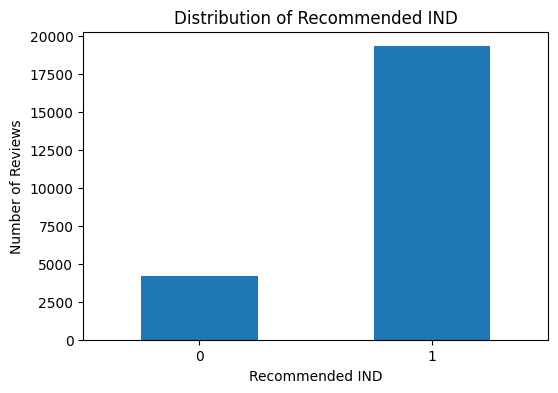

In [8]:
import matplotlib.pyplot as plt

target_counts = df["Recommended IND"].value_counts().sort_index()

print("Target distribution:")
print(target_counts)

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Distribution of Recommended IND")
plt.xlabel("Recommended IND")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

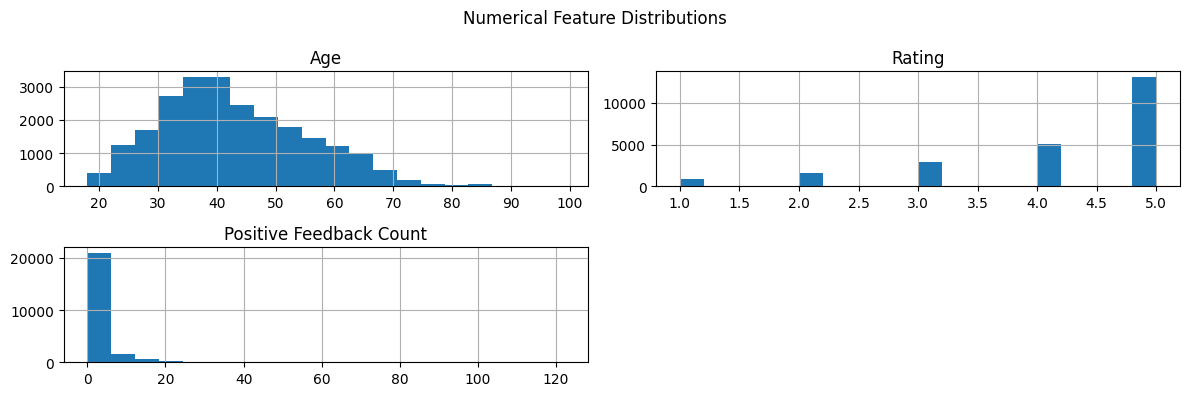

In [9]:
numeric_features = [
    "Age",
    "Rating",
    "Positive Feedback Count"
]

df[numeric_features].hist(
    figsize=(12, 4),
    bins=20
)

plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

Recommendation percentage by rating:


Recommended IND,0,1
Rating,,
1,98.10,1.90
2,93.99,6.01
3,58.59,41.41
4,3.31,96.69
5,0.19,99.81


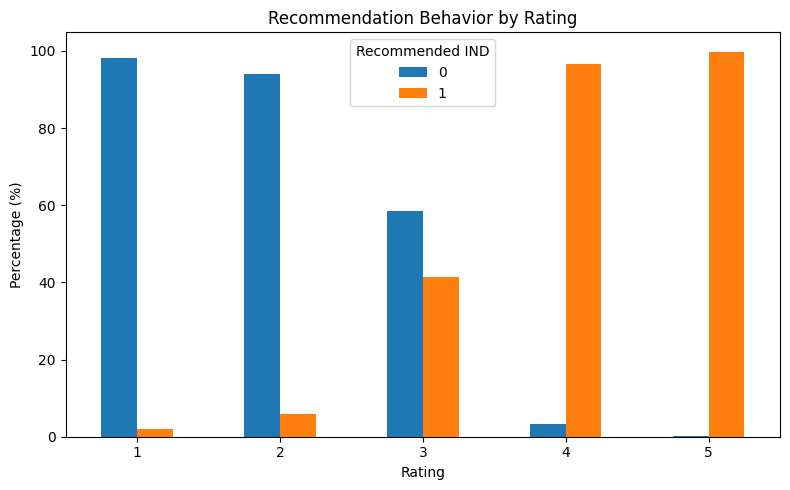

In [10]:
recommendation_by_rating = pd.crosstab(
    df["Rating"],
    df["Recommended IND"],
    normalize="index"
) * 100

print("Recommendation percentage by rating:")
display(recommendation_by_rating.round(2))

recommendation_by_rating.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Recommendation Behavior by Rating")
plt.xlabel("Rating")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Recommended IND")
plt.tight_layout()
plt.show()

Top product departments:


Department Name
Tops        10468
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Trend         119
Name: count, dtype: int64

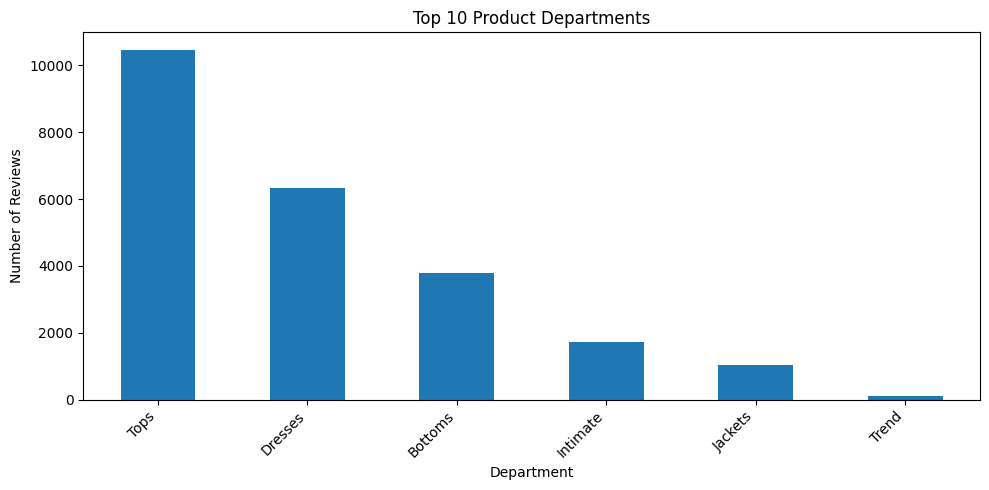

In [11]:
category_counts = df["Department Name"].value_counts()

print("Top product departments:")
display(category_counts.head(10))

plt.figure(figsize=(10, 5))
category_counts.head(10).plot(kind="bar")
plt.title("Top 10 Product Departments")
plt.xlabel("Department")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Review length statistics:


count    23486.000000
mean       297.581666
std        152.572686
min          0.000000
25%        173.000000
50%        292.000000
75%        451.000000
max        508.000000
Name: Review Text, dtype: float64

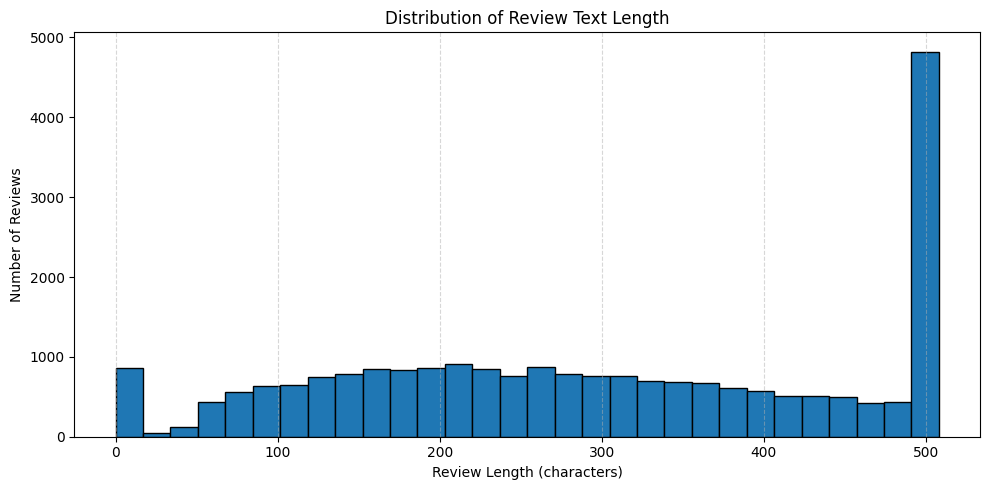

In [13]:
review_length = df["Review Text"].fillna("").str.len()

print("Review length statistics:")
display(review_length.describe())

plt.figure(figsize=(10, 5))

plt.hist(
    review_length,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Review Text Length")
plt.xlabel("Review Length (characters)")
plt.ylabel("Number of Reviews")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

,Word,Frequency
0,dress,10567
1,love,8951
2,size,8772
3,top,7418
4,fit,7325
5,like,7149
6,wear,6439
7,great,6117
8,too,6058
9,just,5608


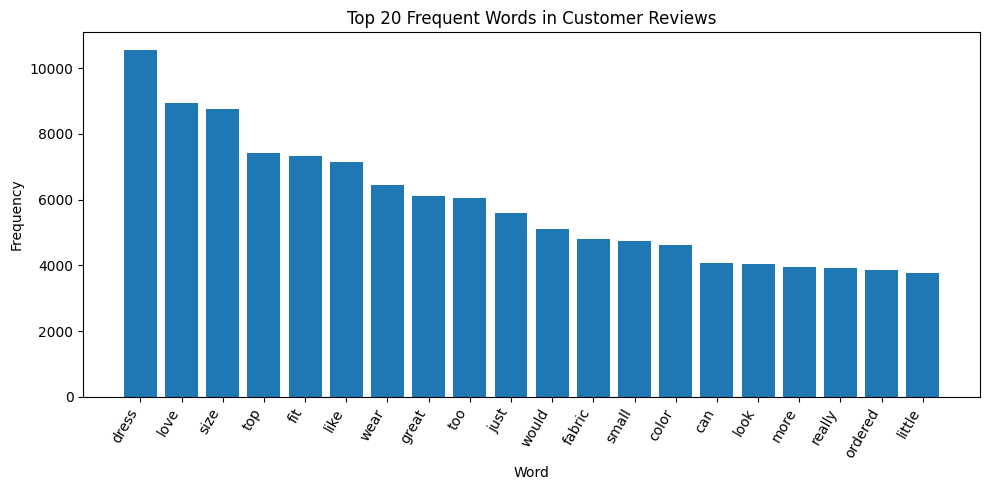

In [14]:
from collections import Counter
import re

text = df["Review Text"].fillna("").str.lower()

words = []

for review in text:
    tokens = re.findall(r"\b[a-z]+\b", review)
    words.extend(tokens)

stop_words = {
    "the", "and", "a", "to", "of", "is", "in", "it",
    "this", "that", "for", "on", "was", "with", "my",
    "i", "but", "so", "very", "as", "have", "had",
    "are", "be", "not", "they", "you", "we", "me"
}

filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

word_counts = Counter(filtered_words)

top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

display(top_words)

plt.figure(figsize=(10, 5))
plt.bar(top_words["Word"], top_words["Frequency"])
plt.title("Top 20 Frequent Words in Customer Reviews")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

,Age,Rating,Recommended IND,Positive Feedback Count
Age,1.00,0.03,0.03,0.04
Rating,0.03,1.00,0.79,-0.06
Recommended IND,0.03,0.79,1.00,-0.07
Positive Feedback Count,0.04,-0.06,-0.07,1.00


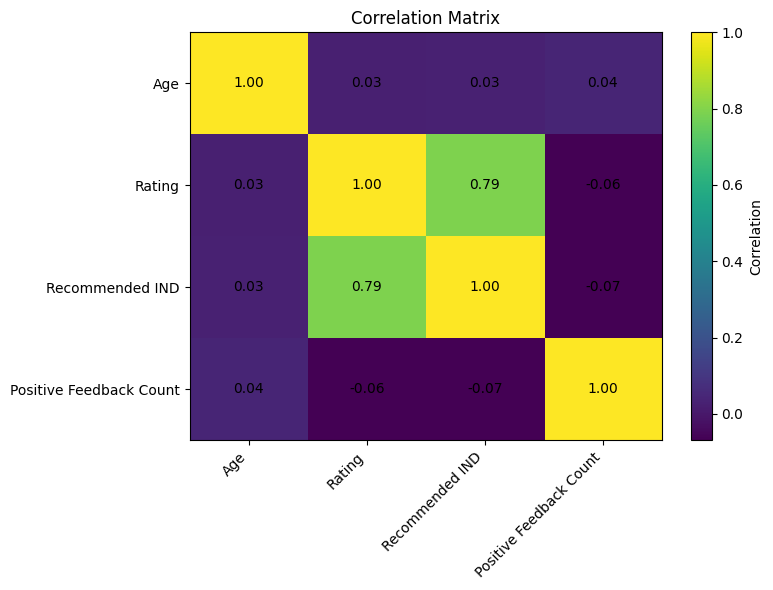

In [16]:
correlation_features = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count"
]

correlation_matrix = df[correlation_features].corr()

display(correlation_matrix.round(2))

plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features
)

# Hiển thị số trên từng ô
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [17]:
# 11. Feature Types

numerical_features = [
    "Clothing ID",
    "Age",
    "Rating",
    "Positive Feedback Count"
]

categorical_features = [
    "Division Name",
    "Department Name",
    "Class Name"
]

text_features = [
    "Title",
    "Review Text"
]

target = "Recommended IND"

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nText features:")
print(text_features)

print("\nTarget variable:")
print(target)

Numerical features:
['Clothing ID', 'Age', 'Rating', 'Positive Feedback Count']

Categorical features:
['Division Name', 'Department Name', 'Class Name']

Text features:
['Title', 'Review Text']

Target variable:
Recommended IND


In [18]:
feature_type_df = pd.DataFrame({
    "Feature": numerical_features + categorical_features + text_features + [target],
    "Type": (
        ["Numerical"] * len(numerical_features) +
        ["Categorical"] * len(categorical_features) +
        ["Text"] * len(text_features) +
        ["Target"] 
    )
})

feature_type_df["Pandas dtype"] = feature_type_df["Feature"].map(df.dtypes)

display(feature_type_df)

,Feature,Type,Pandas dtype
0,Clothing ID,Numerical,int64
1,Age,Numerical,int64
2,Rating,Numerical,int64
3,Positive Feedback Count,Numerical,int64
4,Division Name,Categorical,str
5,Department Name,Categorical,str
6,Class Name,Categorical,str
7,Title,Text,str
8,Review Text,Text,str
9,Recommended IND,Target,int64


In [19]:
# 12. Data Representation

representation_info = pd.DataFrame({
    "Item": [
        "Original dataset shape",
        "Numerical features",
        "Categorical features",
        "Text features",
        "Target",
        "Original target dtype"
    ],
    "Value": [
        df.shape,
        numerical_features,
        categorical_features,
        text_features,
        target,
        df[target].dtype
    ]
})

display(representation_info)

,Item,Value
0,Original dataset shape,"(23486, 11)"
1,Numerical features,"[Clothing ID, Age, Rating, Positive Feedback C..."
2,Categorical features,"[Division Name, Department Name, Class Name]"
3,Text features,"[Title, Review Text]"
4,Target,Recommended IND
5,Original target dtype,int64


In [20]:
print("Numerical feature matrix:")
X_numeric = df[numerical_features].copy()

print("Shape:", X_numeric.shape)
print("Dtype:")
print(X_numeric.dtypes)

print("\nCategorical feature matrix:")
X_categorical = df[categorical_features].copy()

print("Shape:", X_categorical.shape)
print("Dtype:")
print(X_categorical.dtypes)

Numerical feature matrix:
Shape: (23486, 4)
Dtype:
Clothing ID                int64
Age                        int64
Rating                     int64
Positive Feedback Count    int64
dtype: object

Categorical feature matrix:
Shape: (23486, 3)
Dtype:
Division Name      str
Department Name    str
Class Name         str
dtype: object


In [21]:
sample_text = df["Review Text"].dropna().iloc[0]

tokens = sample_text.lower().split()

token_to_id = {
    token: idx + 1
    for idx, token in enumerate(dict.fromkeys(tokens))
}

token_ids = [token_to_id[token] for token in tokens]

print("Original review:")
print(sample_text)

print("\nTokens:")
print(tokens)

print("\nToken IDs:")
print(token_ids)

Original review:
Absolutely wonderful - silky and sexy and comfortable

Tokens:
['absolutely', 'wonderful', '-', 'silky', 'and', 'sexy', 'and', 'comfortable']

Token IDs:
[1, 2, 3, 4, 5, 6, 5, 7]


In [22]:
X = df.drop(columns=[target])
y = df[target]

print("Feature data shape:", X.shape)
print("Target shape:", y.shape)

print("Feature data type:")
print(X.dtypes)

print("\nTarget values:")
print(sorted(y.unique()))

print("\nTarget dtype:", y.dtype)

Feature data shape: (23486, 10)
Target shape: (23486,)
Feature data type:
Unnamed: 0                 int64
Clothing ID                int64
Age                        int64
Title                        str
Review Text                  str
Rating                     int64
Positive Feedback Count    int64
Division Name                str
Department Name              str
Class Name                   str
dtype: object

Target values:
[np.int64(0), np.int64(1)]

Target dtype: int64


In [23]:
# 13. Feature Engineering

df_model = df.copy()

# Remove unnecessary index column
df_model = df_model.drop(columns=["Unnamed: 0"])

# Text-based features
df_model["Review Length"] = df_model["Review Text"].fillna("").str.len()
df_model["Title Length"] = df_model["Title"].fillna("").str.len()

# Presence indicators
df_model["Has Review"] = df_model["Review Text"].notna().astype(int)
df_model["Has Title"] = df_model["Title"].notna().astype(int)

print("Original shape:", df.shape)
print("Shape after feature engineering:", df_model.shape)

display(
    df_model[
        [
            "Review Length",
            "Title Length",
            "Has Review",
            "Has Title"
        ]
    ].head()
)

Original shape: (23486, 11)
Shape after feature engineering: (23486, 14)


,Review Length,Title Length,Has Review,Has Title
0,53,0,1,0
1,303,0,1,0
2,500,23,1,1
3,124,16,1,1
4,192,16,1,1


In [24]:
new_features = [
    "Review Length",
    "Title Length",
    "Has Review",
    "Has Title"
]

display(
    df_model[new_features].describe()
)

,Review Length,Title Length,Has Review,Has Title
count,23486.000000,23486.000000,23486.000000,23486.000000
mean,297.581666,15.998808,0.964021,0.837776
std,152.572686,11.244639,0.186241,0.368664
min,0.000000,0.000000,0.000000,0.000000
25%,173.000000,9.000000,1.000000,1.000000
50%,292.000000,15.000000,1.000000,1.000000
75%,451.000000,23.000000,1.000000,1.000000
max,508.000000,52.000000,1.000000,1.000000


In [25]:
# 14. Train/Test Split

from sklearn.model_selection import train_test_split

target = "Recommended IND"

X = df_model.drop(columns=[target])
y = df_model[target]

# 70% Train, 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split temporary set into 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (16440, 13) (16440,)
Validation: (3523, 13) (3523,)
Test: (3523, 13) (3523,)


In [26]:
split_distribution = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}).sort_index()

display((split_distribution * 100).round(2))

,Train,Validation,Test
Recommended IND,,,
0,17.76,17.77,17.77
1,82.24,82.23,82.23


In [27]:
total = len(df_model)

print(f"Train:      {len(X_train):,} samples ({len(X_train)/total:.1%})")
print(f"Validation: {len(X_val):,} samples ({len(X_val)/total:.1%})")
print(f"Test:       {len(X_test):,} samples ({len(X_test)/total:.1%})")

Train:      16,440 samples (70.0%)
Validation: 3,523 samples (15.0%)
Test:       3,523 samples (15.0%)


In [28]:
# 15. Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Features used for tabular models
numeric_features = [
    "Age",
    "Rating",
    "Positive Feedback Count",
    "Review Length",
    "Title Length",
    "Has Review",
    "Has Title"
]

categorical_features = [
    "Division Name",
    "Department Name",
    "Class Name"
]

X_train_tabular = X_train[
    numeric_features + categorical_features
]

X_val_tabular = X_val[
    numeric_features + categorical_features
]

X_test_tabular = X_test[
    numeric_features + categorical_features
]

print("Tabular training shape:", X_train_tabular.shape)
print("Tabular validation shape:", X_val_tabular.shape)
print("Tabular test shape:", X_test_tabular.shape)

Tabular training shape: (16440, 10)
Tabular validation shape: (3523, 10)
Tabular test shape: (3523, 10)


In [29]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numerical", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [30]:
X_train_processed = preprocessor.fit_transform(X_train_tabular)

X_val_processed = preprocessor.transform(X_val_tabular)

X_test_processed = preprocessor.transform(X_test_tabular)

print("Original training shape:", X_train_tabular.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original validation shape:", X_val_tabular.shape)
print("Processed validation shape:", X_val_processed.shape)

print("Original test shape:", X_test_tabular.shape)
print("Processed test shape:", X_test_processed.shape)

print("\nProcessed dtype:", X_train_processed.dtype)

Original training shape: (16440, 10)
Processed training shape: (16440, 36)
Original validation shape: (3523, 10)
Processed validation shape: (3523, 36)
Original test shape: (3523, 10)
Processed test shape: (3523, 36)

Processed dtype: float64


In [31]:
print("Missing values after preprocessing:")

print("Train:", X_train_processed.shape, 
      "Missing:", pd.isna(X_train_processed).sum())

print("Validation:", X_val_processed.shape, 
      "Missing:", pd.isna(X_val_processed).sum())

print("Test:", X_test_processed.shape, 
      "Missing:", pd.isna(X_test_processed).sum())

Missing values after preprocessing:
Train: (16440, 36) Missing: 0
Validation: (3523, 36) Missing: 0
Test: (3523, 36) Missing: 0


In [32]:
# 16. Baseline Model

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train_processed, y_train)

baseline_pred = baseline.predict(X_val_processed)

baseline_accuracy = accuracy_score(y_val, baseline_pred)
baseline_precision = precision_score(
    y_val,
    baseline_pred,
    zero_division=0
)
baseline_recall = recall_score(
    y_val,
    baseline_pred,
    zero_division=0
)
baseline_f1 = f1_score(
    y_val,
    baseline_pred,
    zero_division=0
)

print("Baseline strategy: Majority Class")
print("Baseline class:", baseline.classes_[baseline.class_prior_.argmax()])

print(f"\nValidation Accuracy:  {baseline_accuracy:.4f}")
print(f"Validation Precision: {baseline_precision:.4f}")
print(f"Validation Recall:    {baseline_recall:.4f}")
print(f"Validation F1-score:  {baseline_f1:.4f}")

Baseline strategy: Majority Class
Baseline class: 1

Validation Accuracy:  0.8223
Validation Precision: 0.8223
Validation Recall:    1.0000
Validation F1-score:  0.9025


In [33]:
baseline_results = pd.DataFrame([{
    "Model": "Baseline",
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1": baseline_f1
}])

display(baseline_results)

,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.822311,0.822311,1.0,0.902492


In [34]:
# 17. Model Training

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    
    "SVM": SVC(
        probability=True,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train_processed, y_train)
    trained_models[name] = model

print("\nAll tabular models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training SVM...
Training Gradient Boosting...

All tabular models trained successfully.


In [35]:
validation_predictions = {}

for name, model in trained_models.items():
    validation_predictions[name] = model.predict(X_val_processed)

print("Validation predictions generated for:")
for name in validation_predictions:
    print("-", name)

Validation predictions generated for:
- Logistic Regression
- Decision Tree
- Random Forest
- SVM
- Gradient Boosting


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Fill missing reviews
train_text = X_train["Review Text"].fillna("")
val_text = X_val["Review Text"].fillna("")
test_text = X_test["Review Text"].fillna("")

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_text = tfidf.fit_transform(train_text)
X_val_text = tfidf.transform(val_text)
X_test_text = tfidf.transform(test_text)

print("Original text samples:", len(train_text))
print("TF-IDF training shape:", X_train_text.shape)
print("TF-IDF validation shape:", X_val_text.shape)
print("TF-IDF test shape:", X_test_text.shape)

Original text samples: 16440
TF-IDF training shape: (16440, 5000)
TF-IDF validation shape: (3523, 5000)
TF-IDF test shape: (3523, 5000)


In [44]:
from sklearn.linear_model import LogisticRegression

text_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

text_model.fit(X_train_text, y_train)

text_pred = text_model.predict(X_val_text)

trained_models["Text Logistic Regression"] = text_model

print("Text-based model trained successfully.")

Text-based model trained successfully.


In [45]:
# 18. Model Comparison

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

comparison_results = []

for name, model in trained_models.items():

    # Text model uses TF-IDF representation
    if name == "Text Logistic Regression":
        predictions = model.predict(X_val_text)
    else:
        predictions = model.predict(X_val_processed)

    comparison_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, predictions),
        "Precision": precision_score(
            y_val, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_val, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_val, predictions, zero_division=0
        )
    })

comparison_df = pd.DataFrame(comparison_results)

display(
    comparison_df.sort_values(
        "F1",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Precision,Recall,F1
0,SVM,0.939540,0.983778,0.942009,0.962440
1,Gradient Boosting,0.938405,0.976190,0.948222,0.962003
2,Logistic Regression,0.935282,0.970060,0.950639,0.960251
3,Random Forest,0.933012,0.964722,0.953400,0.959028
4,Decision Tree,0.915981,0.945529,0.952710,0.949106
5,Text Logistic Regression,0.891002,0.896998,0.979979,0.936655


In [47]:
best_validation_model = comparison_df.loc[
    comparison_df["F1"].idxmax()
]

print("Best model based on Validation F1-score:")
print(best_validation_model)

Best model based on Validation F1-score:
Model             SVM
Accuracy      0.93954
Precision    0.983778
Recall       0.942009
F1            0.96244
Name: 0, dtype: object


In [46]:
# 18. Model Comparison

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

comparison_results = []

# Baseline
comparison_results.append({
    "Model": "Baseline",
    "Accuracy": accuracy_score(y_val, baseline_pred),
    "Precision": precision_score(y_val, baseline_pred, zero_division=0),
    "Recall": recall_score(y_val, baseline_pred, zero_division=0),
    "F1": f1_score(y_val, baseline_pred, zero_division=0)
})

# Other models
for name, model in trained_models.items():

    if name == "Text Logistic Regression":
        predictions = model.predict(X_val_text)
    else:
        predictions = model.predict(X_val_processed)

    comparison_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, predictions),
        "Precision": precision_score(y_val, predictions, zero_division=0),
        "Recall": recall_score(y_val, predictions, zero_division=0),
        "F1": f1_score(y_val, predictions, zero_division=0)
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df = comparison_df.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

display(comparison_df.round(4))

,Model,Accuracy,Precision,Recall,F1
0,SVM,0.9395,0.9838,0.9420,0.9624
1,Gradient Boosting,0.9384,0.9762,0.9482,0.9620
2,Logistic Regression,0.9353,0.9701,0.9506,0.9603
3,Random Forest,0.9330,0.9647,0.9534,0.9590
4,Decision Tree,0.9160,0.9455,0.9527,0.9491
5,Text Logistic Regression,0.8910,0.8970,0.9800,0.9367
6,Baseline,0.8223,0.8223,1.0000,0.9025


In [48]:
# 19. Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

best_model_name = best_validation_model["Model"]
best_model = trained_models[best_model_name]

if best_model_name == "Text Logistic Regression":
    test_predictions = best_model.predict(X_test_text)
    test_probabilities = best_model.predict_proba(X_test_text)[:, 1]
else:
    test_predictions = best_model.predict(X_test_processed)
    test_probabilities = best_model.predict_proba(X_test_processed)[:, 1]

test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(
    y_test, test_predictions, zero_division=0
)
test_recall = recall_score(
    y_test, test_predictions, zero_division=0
)
test_f1 = f1_score(
    y_test, test_predictions, zero_division=0
)
test_roc_auc = roc_auc_score(
    y_test, test_probabilities
)

print("Selected model:", best_model_name)

print(f"\nTest Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-score:  {test_f1:.4f}")
print(f"Test ROC-AUC:   {test_roc_auc:.4f}")

Selected model: SVM

Test Accuracy:  0.9381
Test Precision: 0.9831
Test Recall:    0.9410
Test F1-score:  0.9616
Test ROC-AUC:   0.9720


In [49]:
cm = confusion_matrix(y_test, test_predictions)

print("Confusion Matrix:")

display(
    pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
)

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,579,47
Actual 1,171,2726


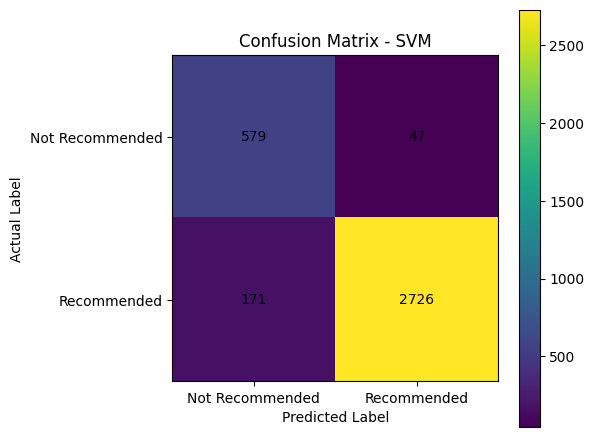

In [50]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Not Recommended", "Recommended"]
)

plt.yticks(
    [0, 1],
    ["Not Recommended", "Recommended"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [51]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Not Recommended",
            "Recommended"
        ],
        digits=4,
        zero_division=0
    )
)

Classification Report:
                 precision    recall  f1-score   support

Not Recommended     0.7720    0.9249    0.8416       626
    Recommended     0.9831    0.9410    0.9616      2897

       accuracy                         0.9381      3523
      macro avg     0.8775    0.9329    0.9016      3523
   weighted avg     0.9455    0.9381    0.9402      3523



In [52]:
# 20. Error Analysis

error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = test_predictions
error_analysis["Correct"] = (
    error_analysis["Actual"] == error_analysis["Predicted"]
)

print("Total test samples:", len(error_analysis))
print("Correct predictions:", error_analysis["Correct"].sum())
print("Incorrect predictions:", (~error_analysis["Correct"]).sum())

Total test samples: 3523
Correct predictions: 3305
Incorrect predictions: 218


In [53]:
errors = error_analysis[
    ~error_analysis["Correct"]
].copy()

display(
    errors[
        [
            "Age",
            "Title",
            "Review Text",
            "Rating",
            "Actual",
            "Predicted"
        ]
    ].head(10)
)

,Age,Title,Review Text,Rating,Actual,Predicted
5615,42,NaN,"Beautiful dress; however, the top was small fo...",3,1,0
13041,42,"Lovely pants, but the strecth out a great deal",I really like the pattern and the cut of these...,3,1,0
1814,31,NaN,It really is such a cute romper. took it on s ...,3,1,0
20194,31,Pretty but not perfect,This is a thick jacquard fabric and the colors...,3,1,0
12235,28,Beautiful color,I wanted to love this dress. i bought the cran...,3,1,0
13916,54,Very delicate but super cute,"I really love this top, but am afraid i may ne...",3,1,0
21179,30,Comfy but...,The top is huge! i wear an xs and am not the b...,3,1,0
18317,25,"Fun color, interesting fit",I'm tall and small chested so the dress didn't...,3,1,0
19699,36,Didn't quite work,"The shirt is quite beautiful, the lace is thic...",3,1,0
22087,54,NaN,Love this top! but unfortunately i returned it...,1,1,0


In [54]:
false_positive = (
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
).sum()

false_negative = (
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
).sum()

print("False Positives:", false_positive)
print("False Negatives:", false_negative)

False Positives: 47
False Negatives: 171


In [55]:
error_rating = errors.groupby(
    ["Actual", "Predicted"]
)["Rating"].agg(
    ["count", "mean"]
)

display(error_rating.round(2))

,,count,mean
Actual,Predicted,,
0,1,47,3.81
1,0,171,2.93


In [56]:
error_by_rating = pd.crosstab(
    errors["Rating"],
    errors["Predicted"],
    normalize="index"
) * 100

display(error_by_rating.round(2))

Predicted,0,1
Rating,,
1,100.00,0.00
2,100.00,0.00
3,91.95,8.05
4,0.00,100.00
5,0.00,100.00


In [57]:
# 21. Model Selection

best_model_name = best_validation_model["Model"]
final_model = trained_models[best_model_name]

best_model_metrics = comparison_df[
    comparison_df["Model"] == best_model_name
].iloc[0]

baseline_metrics = comparison_df[
    comparison_df["Model"] == "Baseline"
].iloc[0]

print("Selected model:", best_model_name)

print("\nValidation performance:")
print(f"Accuracy:  {best_model_metrics['Accuracy']:.4f}")
print(f"Precision: {best_model_metrics['Precision']:.4f}")
print(f"Recall:    {best_model_metrics['Recall']:.4f}")
print(f"F1-score:  {best_model_metrics['F1']:.4f}")

print("\nBaseline F1-score:", f"{baseline_metrics['F1']:.4f}")
print(
    "F1 improvement over baseline:",
    f"{best_model_metrics['F1'] - baseline_metrics['F1']:.4f}"
)

Selected model: SVM

Validation performance:
Accuracy:  0.9395
Precision: 0.9838
Recall:    0.9420
F1-score:  0.9624

Baseline F1-score: 0.9025
F1 improvement over baseline: 0.0599


In [58]:
print("Model selection justification:")
print(
    f"{best_model_name} was selected because it achieved "
    f"the highest validation F1-score among the trained models."
)

print(
    f"Its validation F1-score was "
    f"{best_model_metrics['F1']:.4f}, compared with "
    f"{baseline_metrics['F1']:.4f} for the baseline."
)

print(
    "The selected model will be used as the final model "
    "for persistence and deployment."
)

Model selection justification:
SVM was selected because it achieved the highest validation F1-score among the trained models.
Its validation F1-score was 0.9624, compared with 0.9025 for the baseline.
The selected model will be used as the final model for persistence and deployment.


In [59]:
selection_summary = pd.DataFrame([{
    "Selected Model": best_model_name,
    "Validation F1": best_model_metrics["F1"],
    "Baseline F1": baseline_metrics["F1"],
    "F1 Improvement": (
        best_model_metrics["F1"] -
        baseline_metrics["F1"]
    ),
    "Test F1": test_f1,
    "Test ROC-AUC": test_roc_auc
}])

display(selection_summary.round(4))

,Selected Model,Validation F1,Baseline F1,F1 Improvement,Test F1,Test ROC-AUC
0,SVM,0.9624,0.9025,0.0599,0.9616,0.972


In [60]:
# 22. Model Persistence

import joblib
import os

os.makedirs("ecommerce_model", exist_ok=True)

joblib.dump(
    final_model,
    "ecommerce_model/ecommerce_final_model.pkl"
)

joblib.dump(
    preprocessor,
    "ecommerce_model/ecommerce_preprocessor.pkl"
)

print("Model saved to: ecommerce_model/ecommerce_final_model.pkl")
print("Preprocessor saved to: ecommerce_model/ecommerce_preprocessor.pkl")

Model saved to: ecommerce_model/ecommerce_final_model.pkl
Preprocessor saved to: ecommerce_model/ecommerce_preprocessor.pkl


In [61]:
print("Saved files:")

for file in os.listdir("ecommerce_model"):
    print("-", file)

Saved files:
- ecommerce_final_model.pkl
- ecommerce_preprocessor.pkl


In [62]:
loaded_model = joblib.load(
    "ecommerce_model/ecommerce_final_model.pkl"
)

loaded_preprocessor = joblib.load(
    "ecommerce_model/ecommerce_preprocessor.pkl"
)

loaded_test_data = loaded_preprocessor.transform(
    X_test_tabular
)

loaded_predictions = loaded_model.predict(
    loaded_test_data
)

print("Loaded model:", type(loaded_model).__name__)
print("Loaded preprocessor:", type(loaded_preprocessor).__name__)

print(
    "Predictions identical:",
    (loaded_predictions == test_predictions).all()
)

Loaded model: SVC
Loaded preprocessor: ColumnTransformer
Predictions identical: True


In [63]:
# 23. Inference Test

new_customer = pd.DataFrame({
    "Age": [30],
    "Rating": [5],
    "Positive Feedback Count": [2],
    "Review Length": [120],
    "Title Length": [20],
    "Has Review": [1],
    "Has Title": [1],
    "Division Name": ["General"],
    "Department Name": ["Dresses"],
    "Class Name": ["Dresses"]
})

display(new_customer)

,Age,Rating,Positive Feedback Count,Review Length,Title Length,Has Review,Has Title,Division Name,Department Name,Class Name
0,30,5,2,120,20,1,1,General,Dresses,Dresses


In [64]:
new_customer_processed = loaded_preprocessor.transform(
    new_customer
)

prediction = loaded_model.predict(
    new_customer_processed
)[0]

prediction_probability = loaded_model.predict_proba(
    new_customer_processed
)[0]

print("Predicted Recommended IND:", prediction)

if prediction == 1:
    print("Prediction: Recommended")
else:
    print("Prediction: Not Recommended")

print("\nClass probabilities:")
print(f"Not Recommended (0): {prediction_probability[0]:.4f}")
print(f"Recommended (1):     {prediction_probability[1]:.4f}")

Predicted Recommended IND: 1
Prediction: Recommended

Class probabilities:
Not Recommended (0): 0.0000
Recommended (1):     1.0000


In [65]:
print("=== Inference Test ===")

print("Input shape:", new_customer.shape)
print("Processed shape:", new_customer_processed.shape)
print("Model:", type(loaded_model).__name__)
print("Preprocessor:", type(loaded_preprocessor).__name__)
print("Prediction:", prediction)

=== Inference Test ===
Input shape: (1, 10)
Processed shape: (1, 36)
Model: SVC
Preprocessor: ColumnTransformer
Prediction: 1


In [66]:
# Text → Tokens → Token IDs → Embeddings

import numpy as np

sample_text = df["Review Text"].dropna().iloc[0]

# 1. Tokenization
tokens = sample_text.lower().split()

# 2. Create a simple vocabulary
vocabulary = {token: idx + 1 for idx, token in enumerate(dict.fromkeys(tokens))}

# 3. Convert tokens to Token IDs
token_ids = [vocabulary[token] for token in tokens]

# 4. Create simple embedding vectors
embedding_dim = 8
np.random.seed(42)

embedding_matrix = np.random.normal(
    size=(len(vocabulary) + 1, embedding_dim)
)

# 5. Convert Token IDs to Embeddings
embeddings = embedding_matrix[token_ids]

print("Original text:")
print(sample_text)

print("\nTokens:")
print(tokens)

print("\nToken IDs:")
print(token_ids)

print("\nEmbedding shape:")
print(embeddings.shape)

print("\nEmbedding representation:")
print(embeddings)

Original text:
Absolutely wonderful - silky and sexy and comfortable

Tokens:
['absolutely', 'wonderful', '-', 'silky', 'and', 'sexy', 'and', 'comfortable']

Token IDs:
[1, 2, 3, 4, 5, 6, 5, 7]

Embedding shape:
(8, 8)

Embedding representation:
[[-0.46947439  0.54256004 -0.46341769 -0.46572975  0.24196227 -1.91328024
  -1.72491783 -0.56228753]
 [-1.01283112  0.31424733 -0.90802408 -1.4123037   1.46564877 -0.2257763
   0.0675282  -1.42474819]
 [-0.54438272  0.11092259 -1.15099358  0.37569802 -0.60063869 -0.29169375
  -0.60170661  1.85227818]
 [-0.01349722 -1.05771093  0.82254491 -1.22084365  0.2088636  -1.95967012
  -1.32818605  0.19686124]
 [ 0.73846658  0.17136828 -0.11564828 -0.3011037  -1.47852199 -0.71984421
  -0.46063877  1.05712223]
 [ 0.34361829 -1.76304016  0.32408397 -0.38508228 -0.676922    0.61167629
   1.03099952  0.93128012]
 [ 0.73846658  0.17136828 -0.11564828 -0.3011037  -1.47852199 -0.71984421
  -0.46063877  1.05712223]
 [-0.83921752 -0.30921238  0.33126343  0.9755451